**Goal**

To build a machine learning model that predicts EV sales quantity based on historical trends, state, and vehicle category to support future demand forecasting.

Importing the Libaray


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
saledf=pd.read_csv('/content/ev_sales_ml.csv')

In [3]:
saledf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95985 entries, 0 to 95984
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               95985 non-null  int64 
 1   Month              95985 non-null  int64 
 2   State              95985 non-null  object
 3   Vehicle_Category   95985 non-null  object
 4   Vehicle_Type       95985 non-null  object
 5   EV_Sales_Quantity  95985 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 4.4+ MB


In [4]:
saledf.isnull().sum()

,0
Year,0
Month,0
State,0
Vehicle_Category,0
Vehicle_Type,0
EV_Sales_Quantity,0


In [5]:
saledf.duplicated().sum()

np.int64(55938)

In [6]:
#Their are too many rows with the same entry but they are of differnt date so we will club it
saledf = saledf.groupby(
    ['Year', 'Month', 'State', 'Vehicle_Category', 'Vehicle_Type'],
    as_index=False
)['EV_Sales_Quantity'].sum()

saledf

,Year,Month,State,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014,1,Andaman & Nicobar Island,2-Wheelers,2W_Personal,0
1,2014,1,Andaman & Nicobar Island,2-Wheelers,2W_Shared,0
2,2014,1,Andaman & Nicobar Island,3-Wheelers,3W_Shared,0
3,2014,1,Andaman & Nicobar Island,4-Wheelers,4W_Personal,0
4,2014,1,Andaman & Nicobar Island,4-Wheelers,4W_Shared,0
...,...,...,...,...,...,...
34870,2023,12,West Bengal,4-Wheelers,4W_Personal,138
34871,2023,12,West Bengal,4-Wheelers,4W_Shared,22
34872,2023,12,West Bengal,Bus,Bus,0
34873,2023,12,West Bengal,Bus,Institution Bus,0


In [7]:
saledf.duplicated(
    subset=['Year','Month','State','Vehicle_Category','Vehicle_Type']
).sum()

np.int64(0)

Text(0, 0.5, 'Total EV Sales Quantity')

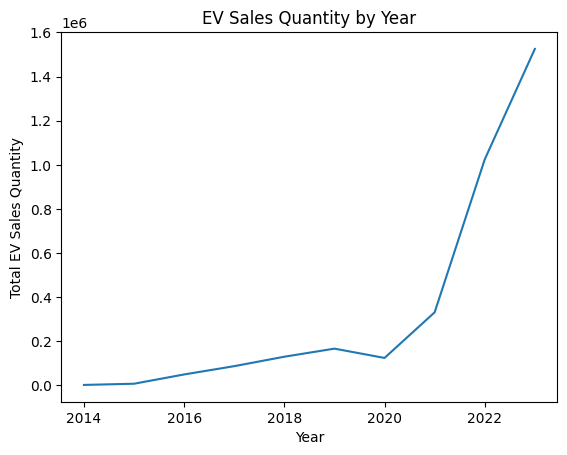

In [8]:
yearly_sales = saledf.groupby('Year')['EV_Sales_Quantity'].sum().reset_index()

plt.plot(yearly_sales['Year'], yearly_sales['EV_Sales_Quantity'])
plt.title('EV Sales Quantity by Year')
plt.xlabel('Year')
plt.ylabel('Total EV Sales Quantity')

In [9]:
saledf = saledf.sort_values(['Year','Month','State','Vehicle_Category','Vehicle_Type'])

In [10]:
#use the last month sale
saledf['lag_1'] = saledf.groupby(['State','Vehicle_Category','Vehicle_Type'])['EV_Sales_Quantity'].shift(1)
#use the last year sale of that month
saledf['lag_12'] = saledf.groupby(['State','Vehicle_Category','Vehicle_Type'])['EV_Sales_Quantity'].shift(12)

In [11]:
a=saledf.groupby(
    ['Year', 'Month'],
    as_index=False
)[['EV_Sales_Quantity','lag_1','lag_12']].sum()
print(a.head(24))

    Year  Month  EV_Sales_Quantity   lag_1  lag_12
0   2014      1                232     0.0     0.0
1   2014      2                171   232.0     0.0
2   2014      3                220   171.0     0.0
3   2014      4                252   220.0     0.0
4   2014      5                186   252.0     0.0
5   2014      6                149   186.0     0.0
6   2014      7                199   149.0     0.0
7   2014      8                180   199.0     0.0
8   2014      9                168   180.0     0.0
9   2014     10                188   168.0     0.0
10  2014     11                210   188.0     0.0
11  2014     12                237   210.0     0.0
12  2015      1                174   237.0   232.0
13  2015      2                182   174.0   171.0
14  2015      3                222   182.0   220.0
15  2015      4                175   222.0   252.0
16  2015      5                195   175.0   186.0
17  2015      6                287   177.0   149.0
18  2015      7                

In [12]:
saledf = saledf.fillna(0)
saledf.shape

(34875, 8)

Now we will Train the model and Evaluate the R^(2) and RMSE for each Models

In [13]:
#import the libaray
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost
from xgboost.sklearn import XGBClassifier

Since this is time-series data, using a random train-test split would introduce bias and data leakage by mixing past and future observations.

In [14]:
#splitting into train and test data
train = saledf[saledf['Year'] <= 2021]
test = saledf[saledf['Year'] > 2021]

x_train = train.drop('EV_Sales_Quantity', axis=1)
y_train = train['EV_Sales_Quantity']

x_test = test.drop('EV_Sales_Quantity', axis=1)
y_test = test['EV_Sales_Quantity']

In [15]:
from sklearn.preprocessing import OneHotEncoder
#Encoding function
def encode_data(x_train, x_test, categorical_cols):
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    encoded_train = encoder.fit_transform(x_train[categorical_cols])           #Train data
    encoded_df_train = pd.DataFrame(
        encoded_train,
        columns=encoder.get_feature_names_out(categorical_cols),
        index=x_train.index)

    x_train = x_train.drop(columns=categorical_cols)
    x_train = pd.concat([x_train, encoded_df_train], axis=1)

    encoded_test = encoder.transform(x_test[categorical_cols])           #Test data
    encoded_df_test = pd.DataFrame(
        encoded_test,
        columns=encoder.get_feature_names_out(categorical_cols),
        index=x_test.index)

    x_test = x_test.drop(columns=categorical_cols)
    x_test = pd.concat([x_test, encoded_df_test], axis=1)

    return x_train, x_test, encoder

In [16]:
categorical_cols = ['State', 'Vehicle_Category', 'Vehicle_Type']

x_train, x_test, encoder = encode_data(x_train, x_test, categorical_cols)

In [17]:
#LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)

r2_train_lr = r2_score(y_train, lr.predict(x_train))
r2_test_lr = r2_score(y_test, y_pred)

print("R2 Score Train:", r2_train_lr)
print("R2 Score Test:", r2_test_lr)
print("RMSE:", rmse_lr)

R2 Score Train: 0.9127387499711024
R2 Score Test: 0.9274527479283361
RMSE: 385.4185278479062


In [18]:
#XGBRegressor

xgbr = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    reg_alpha=0.1,
    reg_lambda=6,
    random_state=42,
    early_stopping_rounds=50
)

xgbr.fit(x_train, y_train, eval_set=[(x_test, y_test)], verbose=False)

y_pred = xgbr.predict(x_test)

mse_xgbr = mean_squared_error(y_test, y_pred)
rmse_xgbr = np.sqrt(mse_xgbr)

r2_train_xgbr = r2_score(y_train, xgbr.predict(x_train))
r2_test_xgbr = r2_score(y_test, y_pred)

print("R2 Score Train:", r2_train_xgbr)
print("R2 Score Test:", r2_test_xgbr)
print("RMSE:", rmse_xgbr)

R2 Score Train: 0.9910579919815063
R2 Score Test: 0.8170068860054016
RMSE: 612.1240683064177


In [19]:
#RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42
)
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)

r2_train_rf = r2_score(y_train, rf.predict(x_train))
r2_test_rf = r2_score(y_test, y_pred)

print("R2 Score Train:", r2_train_rf)
print("R2 Score Test:", r2_test_rf)
print("RMSE:", rmse_rf)

R2 Score Train: 0.9492901345208229
R2 Score Test: 0.7362871794999433
RMSE: 734.8314351532467


TimeSeriesSplit ensures that future data is never used to predict the past, making evaluation more realistic.

In [20]:
from sklearn.model_selection import TimeSeriesSplit

In [21]:
X = saledf.drop('EV_Sales_Quantity', axis=1).sort_values(['Year','Month','State','Vehicle_Category','Vehicle_Type'])
y = saledf['EV_Sales_Quantity']

In [22]:
tscv = TimeSeriesSplit(n_splits=6)

r2_train_scores = []
r2_test_scores = []
rmse = []

categorical_cols = ['State', 'Vehicle_Category', 'Vehicle_Type']

for train_index, test_index in tscv.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]      # Split raw data first
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    X_train, X_test, encoder = encode_data(X_train, X_test, categorical_cols)

    lr = LinearRegression()
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_test)

    r2_train_lr_t = r2_score(y_train, lr.predict(X_train))
    r2_train_scores.append(r2_train_lr_t)

    r2_test_lr_t = r2_score(y_test, y_pred)
    r2_test_scores.append(r2_test_lr_t)

    rmse_lr_t = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse.append(rmse_lr_t)

print("R2_Train scores for each fold:", r2_train_scores)
r2_train_lr_timesplit = np.mean(r2_train_scores[2:])      #In the early stage data is less so that lower the mean so i exclude it
print("Mean R2_train:",r2_train_lr_timesplit,'\n')

print("R2_Test scores for each fold:", r2_test_scores)
r2_test_lr_timesplit = np.mean(r2_test_scores[2:])       #In the early stage data is less so that lower the mean so i exclude it
print("Mean R2_test:",r2_test_lr_timesplit,'\n')

print("RMSE for each fold:", rmse)
rmse_lr_timesplit = np.mean(rmse[2:])       #In the early stage data is less so that lower the mean so i exclude it
print("Mean RMSE:",rmse_lr_timesplit)

R2_Train scores for each fold: [0.7756793973824283, 0.8530155166271634, 0.9306274933674507, 0.9472620382193943, 0.9269156348277872, 0.9345850922870426]
Mean R2_train: 0.9348475646754187 

R2_Test scores for each fold: [0.8478192417448406, 0.952348703864325, 0.9581278026349606, 0.8762081468935211, 0.918661078925341, 0.9191947128193876]
Mean R2_test: 0.9180479353183025 

RMSE for each fold: [np.float64(48.465401288823344), np.float64(47.890645175435864), np.float64(60.1785740004314), np.float64(91.30632326964482), np.float64(224.16454083415368), np.float64(458.1393434540085)]
Mean RMSE: 208.4471953895596


In [23]:
tscv = TimeSeriesSplit(n_splits=6)

r2_train_scores = []
r2_test_scores = []
rmse= []

categorical_cols = ['State', 'Vehicle_Category', 'Vehicle_Type']

for train_index, test_index in tscv.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]      # Split raw data first
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    X_train, X_test, encoder = encode_data(X_train, X_test, categorical_cols)

    xgbr = XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        reg_alpha=0.1,
        reg_lambda=6,
        random_state=42,
        early_stopping_rounds=50
    )

    xgbr.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    y_pred = xgbr.predict(X_test)

    r2_train_xgbr_t = r2_score(y_train, xgbr.predict(X_train))
    r2_train_scores.append(r2_train_xgbr_t)

    r2_test_xgbr_t = r2_score(y_test, y_pred)
    r2_test_scores.append(r2_test_xgbr_t)

    rmse_xgbr_t = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse.append(rmse_xgbr_t)

print("R2_Train scores for each fold:", r2_train_scores)
r2_train_xgb_timesplit = np.mean(r2_train_scores[2:])       #In the early stage data is less so that lower the mean so i exclude it
print("Mean R2_train:", r2_train_xgb_timesplit,'\n')

print("R2_Test scores for each fold:", r2_test_scores)
r2_test_xgb_timesplit = np.mean(r2_test_scores[2:])      #In the early stage data is less so that lower the mean so i exclude it
print("Mean R2_test:", r2_test_xgb_timesplit,'\n')

print("RMSE for each fold:", rmse)                #In the early stage data is less so that lower the mean so i exclude it
rmse_xgb_timesplit = np.mean(rmse[2:])
print("Mean RMSE:", rmse_xgb_timesplit)

R2_Train scores for each fold: [0.9870710968971252, 0.9851688146591187, 0.9974387884140015, 0.973158061504364, 0.9890229105949402, 0.9926680326461792]
Mean R2_train: 0.9880719482898712 

R2_Test scores for each fold: [0.06903475522994995, 0.6880110502243042, 0.8990283012390137, 0.8298032283782959, 0.6687120199203491, 0.8836235404014587]
Mean R2_test: 0.8202917724847794 

RMSE for each fold: [np.float64(119.87225866912452), np.float64(122.54142714685308), np.float64(93.44990511298019), np.float64(107.06079428004912), np.float64(452.3978475855074), np.float64(549.8070115958872)]
Mean RMSE: 300.678889643606


In [24]:
tscv = TimeSeriesSplit(n_splits=6)

r2_train_scores = []
r2_test_scores = []
rmse= []

categorical_cols = ['State', 'Vehicle_Category', 'Vehicle_Type']

for train_index, test_index in tscv.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]      # Split raw data first
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    X_train, X_test, encoder = encode_data(X_train, X_test, categorical_cols)

    rf = RandomForestRegressor(
       n_estimators=300,
       max_depth=20,
       min_samples_leaf=5,
       random_state=42
     )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    r2_train_rf_t = r2_score(y_train, rf.predict(X_train))
    r2_train_scores.append(r2_train_rf_t)

    r2_test_rf_t = r2_score(y_test, y_pred)
    r2_test_scores.append(r2_test_rf_t)

    rmse_rf_t = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse.append(rmse_rf_t)

print("R2_Train scores for each fold:", r2_train_scores)
r2_train_rf_timesplit = np.mean(r2_train_scores[2:])          #In the early stage data is less so that lower the mean so i exclude it
print("Mean R2_train:", r2_train_rf_timesplit,'\n')

print("R2_Test scores for each fold:", r2_test_scores)
r2_test_rf_timesplit = np.mean(r2_test_scores[2:])         #In the early stage data is less so that lower the mean so i exclude it
print("Mean R2_test:", r2_test_rf_timesplit,'\n')

print("RMSE for each fold:", rmse)
rmse_rf_timesplit = np.mean(rmse[2:])               #In the early stage data is less so that lower the mean so i exclude it
print("Mean RMSE:", rmse_rf_timesplit)

R2_Train scores for each fold: [0.8513746416328184, 0.9367128053670934, 0.9562018666998644, 0.9724032427440891, 0.9600324713444026, 0.9614990366228436]
Mean R2_train: 0.9625341543528 

R2_Test scores for each fold: [0.08322250614898319, 0.7510739443620238, 0.9126214257919125, 0.8629139431822122, 0.7843095387811289, 0.8541759650132881]
Mean R2_test: 0.8535052181921354 

RMSE for each fold: [np.float64(118.95533181396881), np.float64(109.45825179033919), np.float64(86.93236467825318), np.float64(96.08408639625294), np.float64(365.0338855806011), np.float64(615.4492625328808)]
Mean RMSE: 290.874899796997


To make the Dicision for the best model

In [25]:
models = ['Linear', 'XGBoost', 'RandomForest']

# Normal split results
r2_train = [r2_train_lr, r2_train_xgbr, r2_train_rf]
r2_test = [r2_test_lr, r2_test_xgbr, r2_test_rf]
rmse = [rmse_lr, rmse_xgbr, rmse_rf]

# TimeSeriesSplit results
r2_train_ts = [r2_train_lr_timesplit, r2_train_xgb_timesplit, r2_train_rf_timesplit]
r2_test_ts = [r2_test_lr_timesplit, r2_test_xgb_timesplit, r2_test_rf_timesplit]
rmse_ts = [rmse_lr_timesplit, rmse_xgb_timesplit, rmse_rf_timesplit]

In [26]:
final_df = pd.DataFrame({
    "Model": models,

    "Train R2 (Normal)": r2_train,
    "Test R2 (Normal)": r2_test,
    "RMSE (Normal)": rmse,

    "Train R2 (TimeSplit)": r2_train_ts,
    "Test R2 (TimeSplit)": r2_test_ts,
    "RMSE (TimeSplit)": rmse_ts
})

final_df

,Model,Train R2 (Normal),Test R2 (Normal),RMSE (Normal),Train R2 (TimeSplit),Test R2 (TimeSplit),RMSE (TimeSplit)
0,Linear,0.912739,0.927453,385.418528,0.934848,0.918048,208.447195
1,XGBoost,0.991058,0.817007,612.124068,0.988072,0.820292,300.678890
2,RandomForest,0.949290,0.736287,734.831435,0.962534,0.853505,290.874900


PLotting the R^(2) of Train v/s Test for both Normal-Split and Timesplit

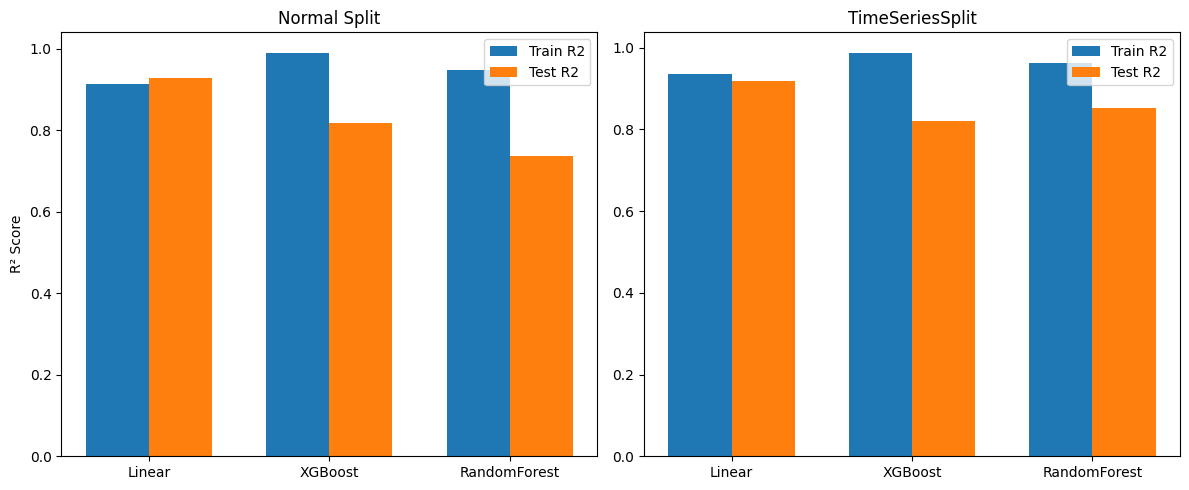

In [27]:
a = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 Normal Split
axes[0].bar(a - width/2, r2_train, width, label='Train R2')
axes[0].bar(a + width/2, r2_test, width, label='Test R2')

axes[0].set_title('Normal Split')
axes[0].set_xticks(a)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('R² Score')
axes[0].legend()


# 🔹 TimeSeriesSplit
axes[1].bar(a - width/2, r2_train_ts, width, label='Train R2')
axes[1].bar(a + width/2, r2_test_ts, width, label='Test R2')

axes[1].set_title('TimeSeriesSplit')
axes[1].set_xticks(a)
axes[1].set_xticklabels(models)
axes[1].legend()


plt.tight_layout()
plt.show()

IN Normal-split                                 

1.   Linear Regression shows balanced performance with similar train and test   R² → good generalization
2. XGBoost shows high overfitting (train ≈ 0.99 vs test ≈ 0.82)
3. Random Forest also shows overfitting, though less severe than XGBoost

IN Timesplit

1.   Linear Regression remains stable and consistent, making it reliable
2. XGBoost still overfits despite time-aware validation
3. Random Forest shows moderate overfitting but better generalization than XGBoost

PLotting the RMSE of Train v/s Test for both Normal-Split and Timesplit

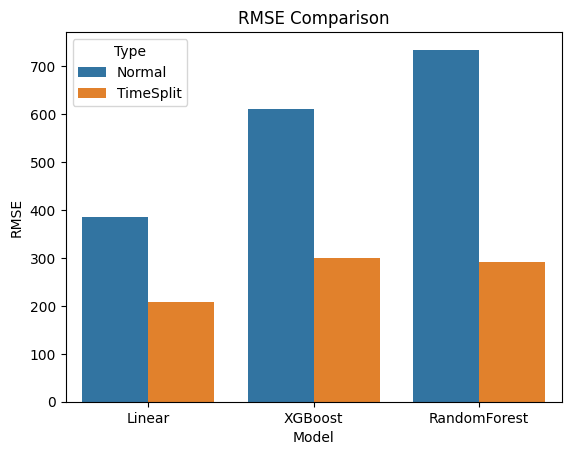

In [28]:
df_rmse = pd.DataFrame({
    'Model': models * 2,
    'RMSE': rmse + rmse_ts,
    'Type': ['Normal']*3 + ['TimeSplit']*3
})

sns.barplot(data=df_rmse, x='Model', y='RMSE', hue='Type')
plt.title('RMSE Comparison')
plt.show()

RMSE for the Linear Regression is the Lowest as compare to both XGBoost and RandomForest

Conclusion


Linear Regression is selected as the final model due to its consistent performance across both Normal Split and TimeSeriesSplit, and also RMSE for the Linear Regression is the Lowest.

Linear(Normal-split) R^(2) :- 92.74% (test_r2)

Linear(TimeSplit) R^(2) :- 91.80% (test_r2)